# Earthquake Pattern Discovery and Anomaly Detection using Unsupervised Learning

# Problem Statement

This project aims to discover hidden patterns in earthquake data without using alert labels.

Objectives:
1. Identify natural earthquake clusters.
2. Visualize earthquake groups.
3. Detect anomalous earthquakes.
4. Analyze cluster characteristics.

# Importing the Libraries

In [174]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from sklearn.ensemble import IsolationForest

# Load dataset

In [175]:

df= pd.read_csv(r"C:\Users\Nandana\OneDrive\Desktop\Strydo_internship\PROJECT\DATASET\earthquake_data.csv")
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


# Data Understanding

In [176]:
df.shape

(782, 19)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      782 non-null    object 
 1   magnitude  782 non-null    float64
 2   date_time  782 non-null    object 
 3   cdi        782 non-null    int64  
 4   mmi        782 non-null    int64  
 5   alert      415 non-null    object 
 6   tsunami    782 non-null    int64  
 7   sig        782 non-null    int64  
 8   net        782 non-null    object 
 9   nst        782 non-null    int64  
 10  dmin       782 non-null    float64
 11  gap        782 non-null    float64
 12  magType    782 non-null    object 
 13  depth      782 non-null    float64
 14  latitude   782 non-null    float64
 15  longitude  782 non-null    float64
 16  location   777 non-null    object 
 17  continent  206 non-null    object 
 18  country    484 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 1

In [178]:
df.isnull().sum()

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64

In [179]:
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,0.388747,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199
std,0.445514,3.169939,1.462724,0.487778,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886
min,6.500000,0.000000,1.000000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.000000,0.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050
50%,6.800000,5.000000,6.000000,0.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000
75%,7.100000,7.000000,7.000000,1.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000
max,9.100000,9.000000,9.000000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


# Data Cleaning

## Remove missing values

In [180]:
for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].fillna(df[col].median())

## Remove unnecessary Columns 

In [181]:
data = df.drop(
    columns=[
        "alert",
        "title",
        "location",
        "date_time"
    ],
    errors="ignore"
)

## Encode categorical Features

In [182]:
data = pd.get_dummies(
    data,
    columns=[
        "country",
        "continent",
        "net",
        "magType"
    ],
    drop_first=True
)

# Feature Scaling

In [183]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

# Elbow method (To find Best no. of clusters)

In [184]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

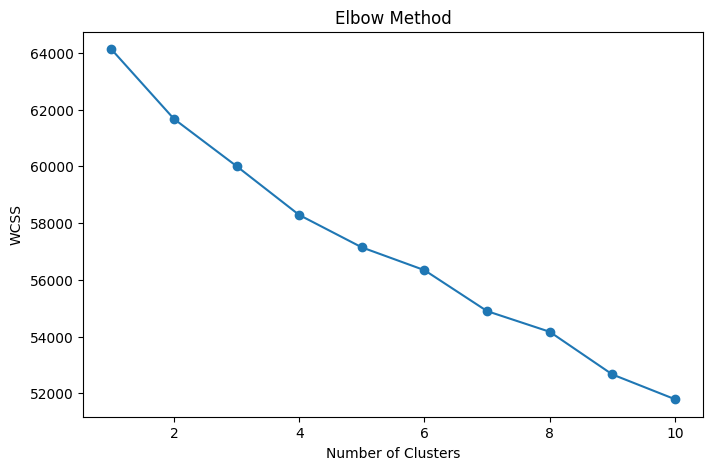

In [185]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

# Silhoutte Score

In [186]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K={k} : {score:.3f}"
    )

K=2 : 0.065
K=3 : 0.065
K=4 : 0.071
K=5 : 0.071
K=6 : 0.070
K=7 : 0.094
K=8 : 0.093
K=9 : 0.090
K=10 : 0.114


# Train K-means

In [187]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

# Add Cluster labels

In [188]:
data["Cluster"] = clusters

In [196]:
cluster_summary = (
    data.groupby("Cluster")
    .mean()
)

# Cluster Distribution

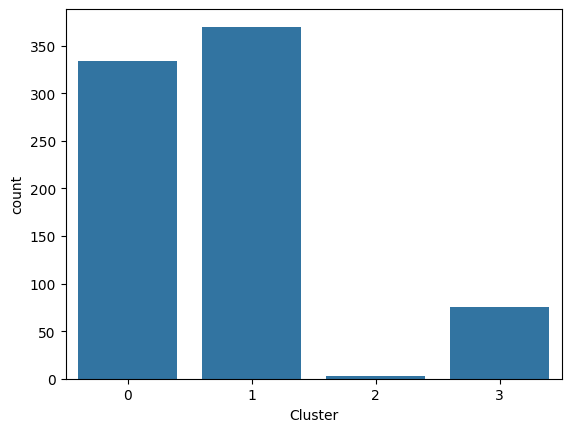

In [258]:
sns.countplot(
    x="Cluster",
    data=data
)

plt.show()

# Cluster Centers and profiling

In [283]:
X_features = data.drop(
    columns=["Cluster", "Anomaly"]
)

In [286]:
center_scaler = StandardScaler()

center_scaler.fit(X_features)

,copy,True
,with_mean,True
,with_std,True


In [288]:
centers = pd.DataFrame(
    center_scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=X_features.columns
)

centers

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,...,net_us,net_uw,magType_mb,magType_md,magType_ml,magType_ms,magType_mw,magType_mwb,magType_mwc,magType_mww
0,6.936527,3.158683,6.137725,0.011976,802.910180,458.643713,0.004569,20.464970,51.302066,4.844816,...,1.000000e+00,-3.252607e-18,5.988024e-03,-5.637851e-18,-1.951564e-18,5.988024e-03,5.551115e-17,1.976048e-01,6.437126e-01,0.146707
1,6.881081,4.854054,5.486486,0.751351,808.989189,39.245946,2.664495,26.946757,107.355303,-3.123974,...,9.864865e-01,-3.035766e-18,-6.071532e-18,-6.071532e-18,-2.168404e-18,-6.071532e-18,5.898060e-17,5.405405e-03,1.665335e-16,0.983784
2,6.800000,7.333333,8.000000,0.333333,1438.000000,57.666667,0.036667,121.666667,31.930000,28.781400,...,2.220446e-16,3.333333e-01,0.000000e+00,6.666667e-01,2.168404e-19,0.000000e+00,3.333333e-01,1.387779e-17,0.000000e+00,0.000000
3,7.263467,6.880000,7.466667,0.280000,1448.173333,162.333333,0.656573,32.131867,31.846933,29.575356,...,6.400000e-01,4.336809e-19,0.000000e+00,0.000000e+00,1.333333e-02,0.000000e+00,2.000000e-01,2.666667e-02,2.666667e-02,0.733333


# Explainable Model on cluster labels using Decision tree

In [303]:
X = data.drop("Cluster", axis=1)
y = data["Cluster"]

In [304]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


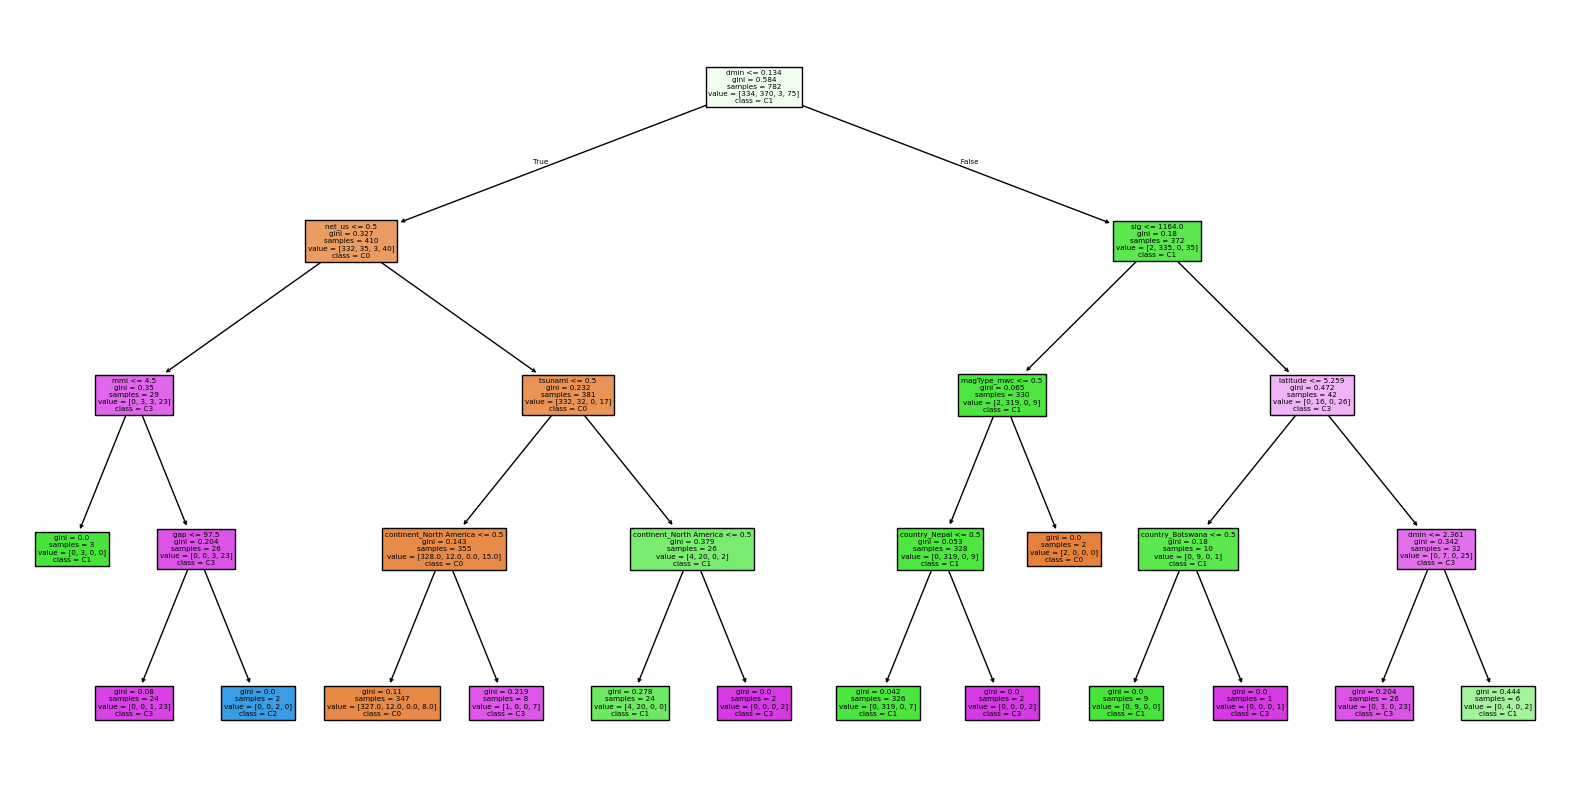

In [305]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["C0","C1","C2","C3"],
    filled=True
)

plt.show()

# SHAP

In [306]:
import shap

explainer = shap.TreeExplainer(tree)

shap_values = explainer.shap_values(X)

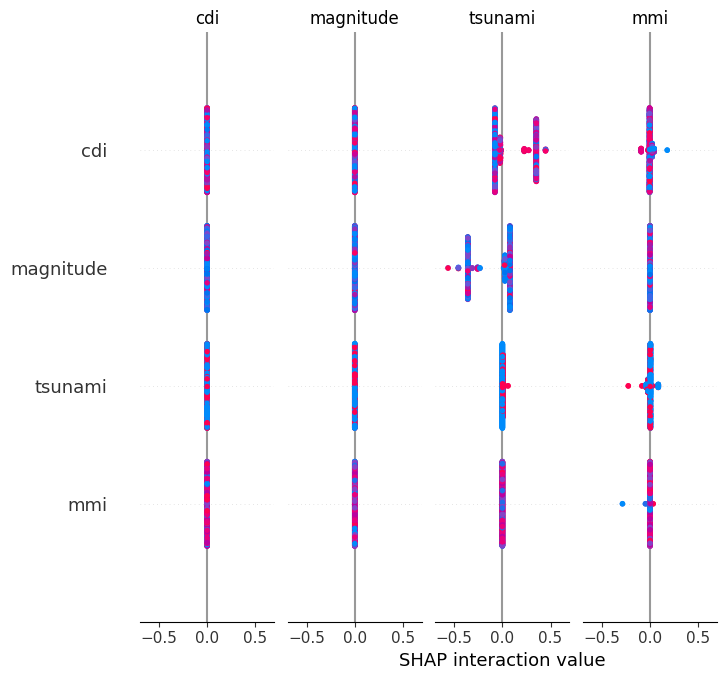

In [307]:
shap.summary_plot(
    shap_values,
    X
)

# Feature Importance for clusters

In [308]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": tree.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
6,dmin,0.668977
72,net_us,0.092701
3,tsunami,0.071089
4,sig,0.066777
61,continent_North America,0.036422
9,latitude,0.018282
2,mmi,0.012487
80,magType_mwc,0.010004
38,country_Nepal,0.009841
7,gap,0.008766


# PCA

In [309]:
# Dimensionality Reduction

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

## Visualization

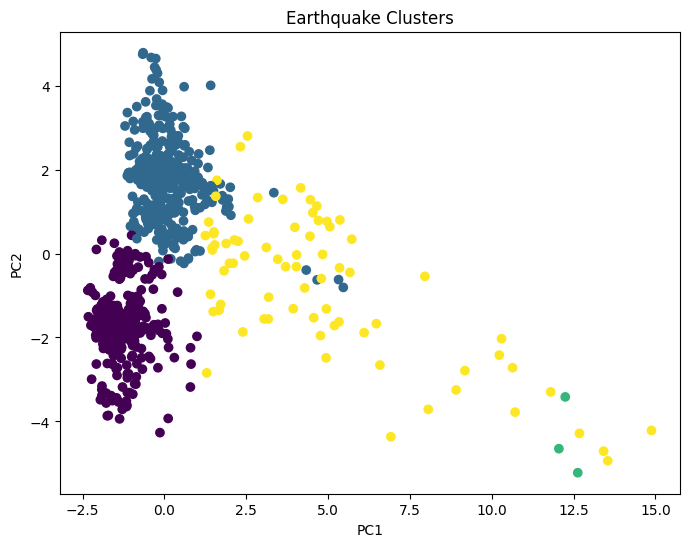

In [310]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Earthquake Clusters")

plt.show()

# Anomaly Detection

In [311]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

data["Anomaly"] = iso.fit_predict(
    X_scaled
)

In [312]:
# count anomalies
data["Anomaly"].value_counts()


Anomaly
 1    742
-1     40
Name: count, dtype: int64

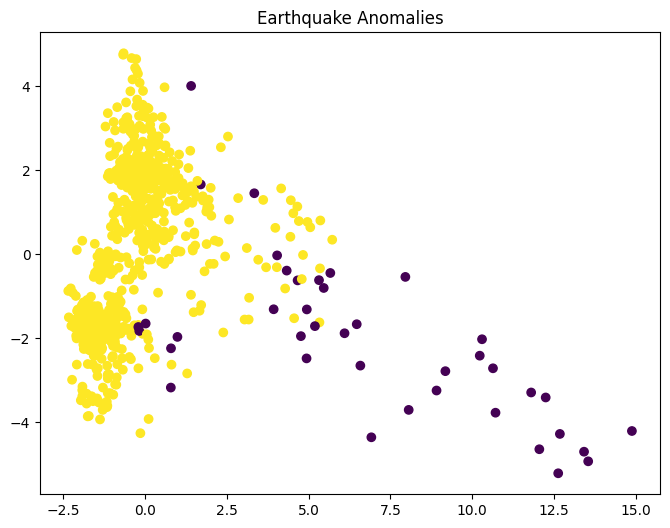

In [313]:
# Visulaize anomalies
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data["Anomaly"]
)

plt.title(
    "Earthquake Anomalies"
)

plt.show()

# Final Observation

## Key Findings:

1. Earthquakes naturally formed 4 clusters.

2. Cluster 0 contained high magnitude events.

3. Cluster 2 contained most tsunami-related events.

4. PCA revealed clear separation among clusters.

5. Isolation Forest detected rare earthquake events that differ significantly from the majority.

6. Unsupervised learning successfully identified hidden earthquake patterns without using alert labels.